# Natural-Text Absent-Relation Kinship Corpus — Closure-Engine Demo

**Artifact:** a document-level **kinship** corpus built from genuinely-natural Wikipedia
introductory prose (Re-DocRED, the completeness-corrected re-annotation of DocRED). One row
per document, no templating, no concatenation. It is the STEP-B host for the experiment:
*does a closure **certificate** beat a confidence-thresholded abstainer on a real-text
**absent-relation** regime?*

This demo loads a curated subset of the **primary `re-docred` slice** and runs the dataset's
**drop-in closure engine** (`kinship.py`, used verbatim by the downstream experiment). Each
document's gold graph has three strata:

1. **Atomic edges** — every annotated family edge (the KB / proof chain); some are flagged
   `locally_justifiable` (a span-local reader could extract them from adjacent-sentence
   co-occurrence + a surface kinship cue like *son / wife / brother*).
2. **Present query edges** — held-out pairs with **no** direct annotated edge and **no** local
   co-occurrence, whose **≥2-hop composition** yields a unique relation (deduction-required).
   `composed_only` types (*grand / uncle / in-law / …*) are **outside DocRED's inventory** ⇒
   provably non-circular.
3. **Absent relation pairs** — both entities are family-participating but lie in **different
   connected components** ⇒ no kinship path (conservative closed-world label).

**What we demonstrate (the round-trip QA from `verify.py`):** the finite-composition closure
engine **reproduces every emitted PRESENT multi-hop gold**, derives **EMPTY (abstains) on
every ABSENT pair** — hallucination-safe by construction — and produces a **human-auditable
derivation trace-graph** for each multi-hop deduction.


In [1]:
# --- Install dependencies (Colab-safe pattern) ---
# The closure engine is pure Python stdlib; only matplotlib is needed for the final plots.
# matplotlib is pre-installed on Colab, so install it ONLY when NOT on Colab (to match Colab's
# version locally) -- pip-installing it on Colab would corrupt pre-loaded C extensions.
import subprocess, sys

def _pip(*a):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

if "google.colab" not in sys.modules:
    _pip("matplotlib==3.10.0")



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports ---
# Engine imports (copied from kinship.py) + json/collections for data handling + matplotlib for plots.
from __future__ import annotations
import json, os
from collections import defaultdict, deque
from typing import Iterable
import matplotlib.pyplot as plt


In [3]:
# --- Data loading helper (GitHub URL with local fallback, for Colab compatibility) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-6/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
# --- Load the curated demo corpus ---
data = load_data()
print("top-level keys:", list(data.keys()))
for d in data["datasets"]:
    print(f"  dataset '{d['dataset']}': {len(d['examples'])} documents")


top-level keys: ['metadata', 'datasets']
  dataset 're-docred': 32 documents


## Configuration

The only tunable knob for this dataset demo is **how many documents** to run the closure
engine over. The engine is a pure-Python finite-table fixpoint, so it is essentially instant;
we start at the absolute minimum (2 documents) and scale up to the full curated subset.
The curated `mini_demo_data.json` orders documents so the first ones exercise all three strata
(present queries **and** absent pairs).

In [5]:
# --- Config (start at the absolute minimum, scale up during testing) ---
MAX_DOCS = 32            # documents to process. MIN that produces output = 2; full subset = 32.
TRACE_MAX_STEPS = 60     # max composition steps to reconstruct for the derivation trace-graph.
MAX_TRACES_TO_SHOW = 3   # how many human-auditable derivation traces to print.


## The drop-in closure engine (`kinship.py`, verbatim)

This is the symbolic half of the pipeline, **copied verbatim** from the dataset's `kinship.py`
(the downstream experiment imports it unchanged). CLUTRR's kinship calculus is a **finite
composition table** over 11 abstract relation *types* — *not* a full relation algebra. The
**sound** closure is a **forward least-fixpoint UNION derivation** over *defined* compositions
only:

- seed every atomic edge `a→b:t` (and its converse `b→a:conv(t)`);
- while changing, for every `a–b–c` and `t1∈D[(a,b)]`, `t2∈D[(b,c)]`, if `rules[t1][t2]=t3`
  is **defined**, add `t3` to `D[(a,c)]`. Undefined compositions add nothing (sound: "unknown",
  never a wrong fact).

Output contract: `|D[query]|==1` → **emit** the relation; `==0` → **abstain** (no path = the
absent-relation case); `>1` → abstain (incompatible derivations). With no connecting path `D`
is empty, so the engine **never invents a kinship** — hallucination-safe by construction.

*(Only the standalone `__main__` self-test at the foot of the file — which read a hardcoded
local path — is omitted; every class and function below is unchanged.)*

In [6]:
#!/usr/bin/env python3
"""Kinship finite-composition closure engine (the symbolic half of the pipeline).

CLUTRR's kinship calculus is a FINITE COMPOSITION TABLE over 11 abstract relation
TYPES -- and, as the dataset card states verbatim, it is NOT a full relation algebra:
"no general intersection/converse closure beyond these rules". A naive port of the
temporal PC-2 engine (Mackworth converse-intersection path-consistency) is therefore
UNSOUND here -- closing the converse constraints makes ~13% of GOLD-clean chains
spuriously collapse to EMPTY, because two derivation orders can yield two different
(individually valid) relations that the table does not reconcile. (We verified this
directly: PC-2-style closure gives 100% accuracy WHEN it answers but only 0.87
singleton-rate, with 2153/16131 clean rows collapsing.)

The SOUND closure for a finite composition table is a FORWARD LEAST-FIXPOINT
*UNION* DERIVATION over DEFINED compositions only -- exactly the backward/forward
chaining that produces CLUTRR's own `gold_proof`, and exactly what the emitted Prolog
`derive/3` predicate computes:

  D[(a,b)] = { t : t derivable for directed pair a->b by composing atomic links }

  * seed: every atomic edge a->b:t adds t to D[(a,b)] and conv(t) to D[(b,a)];
  * close: while changing, for every a-b-c, for t1 in D[(a,b)], t2 in D[(b,c)],
    if rules[t1][t2]=t3 is DEFINED, add t3 to D[(a,c)] (and conv(t3) to D[(c,a)]);
    UNDEFINED compositions add nothing (SOUND: "unknown", never a wrong fact).

OUTPUT CONTRACT (disjunction-preserving Mode-A / abstain-on-collapse Mode-B):
  * |D[query]| == 1  -> EMIT the relation (covered).            [unique derivation]
  * |D[query]| >  1  -> ABSTAIN (Mode-B CONFLICT certificate).  [incompatible derivations]
  * |D[query]| == 0  -> ABSTAIN (no connecting path = universe). [absent-relation / underdetermined]

This contract is hallucination-safe by construction: with no connecting path (the
absent-relation case, entities in different components) D is empty, so the engine
NEVER invents a kinship -- it abstains. The naive single-pass baseline uses ONLY the
seed (atomic) edges and one composition step, so it resolves hop-2 chains but abstains
on hop>=3 (the iteration contrast), while the full fixpoint derives the intermediate
composite edges first and resolves the whole chain.
"""
from __future__ import annotations

from collections import defaultdict, deque
from typing import Iterable


class Kinship:
    """Finite kinship composition calculus parsed from the dataset composition table."""

    def __init__(self, comp_table: dict):
        rt = comp_table["relation_types"]
        self.base: list[str] = list(rt.keys())  # 11 abstract relation types
        self.universe = frozenset(self.base)
        self.empty = frozenset()
        self.symmetric_types = set(comp_table["symmetric_types"])  # {'sibling','SO'}
        self.inv: dict[str, str] = {}
        for a, b in comp_table["inverse_pairs"].items():
            self.inv[a] = b
            self.inv[b] = a
        self.composition_rules = comp_table["composition_rules"]
        self.surface_forms = comp_table["surface_forms"]
        self.surface_reverse = comp_table["surface_reverse"]
        self.label_map = comp_table.get("label_map", {})
        self.label_map_reverse = comp_table.get("label_map_reverse", {})
        # ---- total converse over every base type (sound; no empties) ----
        self._conv: dict[str, str] = {}
        for t in self.base:
            if t in self.symmetric_types:
                self._conv[t] = t
            elif t in self.inv:
                self._conv[t] = self.inv[t]
            elif t == "sibling-in-law":
                # brother/sister-in-law are mutual: converse(sibling-in-law)=sibling-in-law.
                self._conv[t] = t
            else:
                self._conv[t] = t  # sound self-converse fallback (never reached for the 11 types)

    # ------------------------------------------------------------------ ops
    def conv_type(self, t: str) -> str:
        return self._conv[t]

    def compose_types(self, t1: str, t2: str):
        """Defined composition rules[t1][t2]=t3, else None (UNDEFINED == 'unknown')."""
        return self.composition_rules.get(t1, {}).get(t2)

    def label(self, s) -> str:
        s = frozenset(s)
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(t for t in self.base if t in s)

    # ------------------------------------------------------------- surface words
    def surface(self, rel_type: str, gender: str) -> str:
        g = "male" if str(gender).lower().startswith("m") else "female"
        sf = self.surface_forms.get(rel_type)
        if not sf:
            return rel_type
        return sf.get(g, sf.get("male", rel_type))

    def surface_to_type(self, surface_word: str):
        """Return (relation_type, implied_gender) or None for an unknown word."""
        w = str(surface_word).strip().lower()
        rev = self.surface_reverse.get(w)
        if rev is None:
            return None
        return rev[0], rev[1]


# --------------------------------------------------------------------------- #
# Forward least-fixpoint UNION derivation (the sound closure for the finite table)
# --------------------------------------------------------------------------- #
def _seed(kin: Kinship, atomic_edges: list[dict]):
    """Seed D with atomic edges + their converses. Returns (D, nbrs).
    D[(a,b)] = set of types; nbrs[a] = set of directed successors."""
    D: dict = defaultdict(set)
    nbrs: dict = defaultdict(set)

    def add(a, b, t):
        if t not in D[(a, b)]:
            D[(a, b)].add(t)
            nbrs[a].add(b)

    for e in atomic_edges:
        t = e["type"]
        if t not in kin.base:
            continue
        a, b = e["a"], e["b"]
        if a == b:
            continue
        add(a, b, t)
        add(b, a, kin.conv_type(t))
    return D, nbrs


def forward_closure(kin: Kinship, atomic_edges: list[dict], with_prov: bool = False):
    """Forward least-fixpoint union derivation. Returns (D, nbrs, n_fired) or, with
    with_prov, (D, nbrs, n_fired, prov) where prov[(a,c,t3)] = (a,b,c,t1,t2,t3) records
    the FIRST composition that produced type t3 on pair (a,c) (a directed-edge of the
    proof DAG; seed edges map to None).

    D[(a,b)] holds EVERY relation type derivable for the directed pair a->b; closed
    under defined composition + converse. n_fired = number of new type-additions."""
    D, nbrs = _seed(kin, atomic_edges)
    prov: dict = {}
    if with_prov:
        for (a, b), ts in D.items():
            for t in ts:
                prov.setdefault((a, b, t), None)
    Q = deque(D.keys())
    inq = set(D.keys())
    n_fired = 0

    def push(p):
        if p not in inq:
            inq.add(p)
            Q.append(p)

    def emit(a, c, t3, provtuple):
        nonlocal n_fired
        grew = False
        if t3 not in D[(a, c)]:
            D[(a, c)].add(t3)
            nbrs[a].add(c)
            if with_prov:
                prov.setdefault((a, c, t3), provtuple)
            n_fired += 1
            grew = True
        ct3 = kin.conv_type(t3)
        if ct3 not in D[(c, a)]:
            D[(c, a)].add(ct3)
            nbrs[c].add(a)
            if with_prov:
                prov.setdefault((c, a, ct3), (c, a, a, ct3, None, ct3))  # converse marker
        if grew:
            push((a, c)); push((c, a))

    while Q:
        (a, b) = Q.popleft()
        inq.discard((a, b))
        tab = list(D[(a, b)])
        # extend a->b with b->c  =>  a->c
        for c in list(nbrs[b]):
            if c == a:
                continue
            for t1 in tab:
                for t2 in list(D[(b, c)]):
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(a, c, t3, (a, b, c, t1, t2, t3))
        # extend z->a with a->b  =>  z->b   (a is the middle)
        for z in list(nbrs[a]):
            if z == b:
                continue
            for t1 in list(D[(z, a)]):
                for t2 in tab:
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(z, b, t3, (z, a, b, t1, t2, t3))
    if with_prov:
        return D, nbrs, n_fired, prov
    return D, nbrs, n_fired


def naive_single_pass(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> set:
    """BASELINE: ONE composition pass at the query edge using ONLY seed (atomic) edges.

    R = union over intermediates w of {rules[t1][t2] : t1 in seed(u,w), t2 in seed(w,v)}.
    NO fixpoint, NO derived edges. On a hop-k chain only the hop-2 case has an
    intermediate w with BOTH atomic links to the endpoints, so naive resolves hop-2 but
    derives nothing (-> abstain) on hop>=3."""
    D, nbrs = _seed(kin, atomic_edges)
    R: set = set()
    for w in nbrs.get(qsrc, ()):
        if w in (qsrc, qtgt):
            continue
        if (w, qtgt) in D:
            for t1 in D[(qsrc, w)]:
                for t2 in D[(w, qtgt)]:
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        R.add(t3)
    return R


# --------------------------------------------------------------------------- #
# Query wrappers with the Mode-A / Mode-B output contract
# --------------------------------------------------------------------------- #
def _answer_from_set(kin: Kinship, R: set) -> dict:
    R = set(R)
    n = len(R)
    if n == 1:
        t = next(iter(R))
        return {"types": sorted(R), "singleton": True, "answer_type": t,
                "n_derivations": n, "mode_b_conflict": False, "no_path": False}
    if n == 0:
        return {"types": [], "singleton": False, "answer_type": None,
                "n_derivations": 0, "mode_b_conflict": False, "no_path": True}
    # n > 1 : incompatible derivations => Mode-B conflict
    rep = sorted(R, key=lambda t: kin.base.index(t))[0]  # deterministic representative
    return {"types": sorted(R), "singleton": False, "answer_type": rep,
            "n_derivations": n, "mode_b_conflict": True, "no_path": False}


def query_modeA(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> dict:
    """Mode-A forward-closure query. Returns the output-contract decision + n_fired."""
    D, nbrs, n_fired = forward_closure(kin, atomic_edges)
    R = D.get((qsrc, qtgt), set())
    out = _answer_from_set(kin, R)
    out["n_fired"] = n_fired
    return out


def query_naive(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> dict:
    """Naive single-pass query (fresh seed only)."""
    R = naive_single_pass(kin, atomic_edges, qsrc, qtgt)
    return _answer_from_set(kin, R)


def simple_paths_names(atomic_edges: list[dict], qsrc, qtgt, max_paths: int = 3,
                       max_len: int = 12):
    """Up to `max_paths` simple undirected entity paths qsrc..qtgt over the atomic-edge
    graph (feeds Path-of-Thoughts). Returns lists of node names, shortest first."""
    adj: dict = {}
    for e in atomic_edges:
        adj.setdefault(e["a"], set()).add(e["b"])
        adj.setdefault(e["b"], set()).add(e["a"])
    if qsrc not in adj or qtgt not in adj:
        return []
    paths: list[list] = []
    stack = [(qsrc, [qsrc])]
    while stack and len(paths) < max_paths * 4:
        node, path = stack.pop()
        if len(path) > max_len:
            continue
        for nb in sorted(adj.get(node, ())):
            if nb == qtgt:
                paths.append(path + [nb])
            elif nb not in path:
                stack.append((nb, path + [nb]))
    paths.sort(key=len)
    # de-dup
    seen = set(); uniq = []
    for p in paths:
        k = tuple(p)
        if k not in seen:
            seen.add(k); uniq.append(p)
    return uniq[:max_paths]


def derivation_trace(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt,
                     max_steps: int = 60):
    """Reconstruct ONE concrete derivation for (qsrc->qtgt) for the trace-graph:
    which (t1 o t2 -> t3) compositions fire, mirroring the gold backward proof.
    Returns a list of {a,b,c,t1,t2,t3} steps producing the answer type, or [] if the
    query is not a unique-derivation singleton."""
    D, nbrs, _, prov = forward_closure(kin, atomic_edges, with_prov=True)
    target = D.get((qsrc, qtgt), set())
    if len(target) != 1:
        return []
    goal_type = next(iter(target))
    steps = []
    stack = [(qsrc, qtgt, goal_type)]
    seen = set()
    while stack and len(steps) < max_steps:
        key = stack.pop()
        if key in seen:
            continue
        seen.add(key)
        p = prov.get(key)
        if p is None:
            continue  # seed edge (atomic fact) -- a leaf of the proof DAG
        a, b, c, t1, t2, t3 = p
        if t2 is None:
            # converse marker: unfold to the forward edge (b->a : conv(t3))
            stack.append((c, a, kin.conv_type(t3)))
            continue
        steps.append({"a": a, "b": b, "c": c, "t1": t1, "t2": t2, "t3": t3})
        stack.append((a, b, t1))
        stack.append((b, c, t2))
    steps.reverse()
    return steps


## Build the engine and inspect the corpus

The finite composition table is embedded once in `data["metadata"]["composition_table"]`;
we build the `Kinship` engine from it and tally the three strata across the documents we will
process. The `engine_edge_mapping` documented in the dataset is `{a: source, b: target,
type: primitive}` — each atomic edge becomes one seed link for the closure.

In [7]:
# --- Build the Kinship engine from the embedded composition table + inspect strata ---
CT = data["metadata"]["composition_table"]
KIN = Kinship(CT)
print("relation types (11):", KIN.base)
print("symmetric types:    ", sorted(KIN.symmetric_types))
print("converse map:       ", KIN._conv)

# gather the documents we will process (curated subset is a single 're-docred' slice)
docs = []
for d in data["datasets"]:
    docs.extend(d["examples"])
docs = docs[:MAX_DOCS]

n_atomic = n_query = n_absent = n_local = 0
hop_hist = defaultdict(int)
for r in docs:
    gg = json.loads(r["output"])
    n_atomic += len(gg["atomic_edges"])
    n_query  += len(gg["query_edges"])
    n_absent += len(gg["absent_relation_pairs"])
    n_local  += sum(1 for e in gg["atomic_edges"] if e["locally_justifiable"])
    for q in gg["query_edges"]:
        hop_hist[q["hop_count"]] += 1

print(f"\nprocessing {len(docs)} documents:")
print(f"  atomic edges (KB / proof chain): {n_atomic}  (locally-justifiable: {n_local})")
print(f"  PRESENT query edges (>=2-hop):   {n_query}")
print(f"  ABSENT relation pairs:           {n_absent}")
print(f"  present hop histogram:           {dict(sorted(hop_hist.items()))}")


relation types (11): ['child', 'inv-child', 'SO', 'sibling', 'grand', 'inv-grand', 'in-law', 'inv-in-law', 'sibling-in-law', 'un', 'inv-un']
symmetric types:     ['SO', 'sibling']
converse map:        {'child': 'inv-child', 'inv-child': 'child', 'SO': 'SO', 'sibling': 'sibling', 'grand': 'inv-grand', 'inv-grand': 'grand', 'in-law': 'inv-in-law', 'inv-in-law': 'in-law', 'sibling-in-law': 'sibling-in-law', 'un': 'inv-un', 'inv-un': 'un'}

processing 32 documents:
  atomic edges (KB / proof chain): 315  (locally-justifiable: 193)
  PRESENT query edges (>=2-hop):   57
  ABSENT relation pairs:           188
  present hop histogram:           {2: 51, 3: 6}


## Round-trip verification (the `verify.py` QA)

For each document we rebuild the closure input from its atomic edges via the documented
mapping, run the forward least-fixpoint closure once, and then check:

- **PRESENT**: the engine derives the emitted gold `primitive` as a **unique singleton**
  (`|D[(s,t)]|==1` and the type matches);
- **ABSENT**: the engine derives **EMPTY** (`|D[(s,t)]|==0`) ⇒ it abstains, never fabricating
  a relation across disconnected components;
- **CUE**: every `locally_justifiable` atomic edge's declared `surface_cue` is actually
  present in its support span (the readability / non-circularity audit).

In [8]:
# --- Drop-in engine round-trip over the loaded documents (mirrors verify.py) ---
n_q = q_ok = n_abs = abs_ok = cue_checked = cue_ok = 0

for r in docs:
    gg = json.loads(r["output"])
    # rebuild engine input via documented mapping {a:source, b:target, type:primitive}
    edges = [{"a": e["source"], "b": e["target"], "type": e["primitive"]} for e in gg["atomic_edges"]]
    D, nbrs, _ = forward_closure(KIN, edges)
    text = r["input"].lower()
    for e in gg["atomic_edges"]:
        if e["locally_justifiable"]:
            cue_checked += 1
            sp = e["support_span"]
            if e["surface_cue"] and e["surface_cue"] in text[sp[0]:sp[1]]:
                cue_ok += 1
    for q in gg["query_edges"]:
        n_q += 1
        R = D.get((q["source"], q["target"]), set())
        if len(R) == 1 and next(iter(R)) == q["primitive"]:   # unique-derivation singleton == gold
            q_ok += 1
    for p in gg["absent_relation_pairs"]:
        n_abs += 1
        R = D.get((p["source"], p["target"]), set())
        if len(R) == 0:                                       # empty derivation => abstain
            abs_ok += 1

print(f"PRESENT query round-trip: {q_ok}/{n_q} = {q_ok/max(n_q,1):.4f}  (engine reproduces emitted gold)")
print(f"ABSENT  no-derivation:    {abs_ok}/{n_abs} = {abs_ok/max(n_abs,1):.4f}  (engine derives EMPTY => abstains)")
print(f"cue-present pass rate:    {cue_ok}/{cue_checked} = {cue_ok/max(cue_checked,1):.4f}")


PRESENT query round-trip: 57/57 = 1.0000  (engine reproduces emitted gold)
ABSENT  no-derivation:    188/188 = 1.0000  (engine derives EMPTY => abstains)
cue-present pass rate:    193/193 = 1.0000


## Human-auditable derivation trace-graphs

For a deduction-required PRESENT query the engine can reconstruct **one concrete derivation**:
which `(t1 ∘ t2 → t3)` compositions fire, mirroring CLUTRR's own backward proof. This is the
interpretable reasoning trace the pipeline is meant to expose — every multi-hop answer is
backed by an explicit, checkable chain of finite-table rule firings over named entities.

In [9]:
# --- Print human-auditable derivation trace-graphs for a few PRESENT queries ---
shown = 0
for r in docs:
    if shown >= MAX_TRACES_TO_SHOW:
        break
    gg = json.loads(r["output"])
    nodes = {n["entity_id"]: n["surface"] for n in gg["nodes"]}
    edges = [{"a": e["source"], "b": e["target"], "type": e["primitive"]} for e in gg["atomic_edges"]]
    for q in gg["query_edges"]:
        trace = derivation_trace(KIN, edges, q["source"], q["target"], max_steps=TRACE_MAX_STEPS)
        if not trace:
            continue
        s, t = nodes.get(q["source"], q["source"]), nodes.get(q["target"], q["target"])
        gold = KIN.surface(q["primitive"], q["target_gender"]) if q.get("target_gender") else q["primitive"]
        print(f"DOC: {r['metadata_doc_id']!r}")
        print(f"  QUERY: ({s!r} -> {t!r})  hop_count={q['hop_count']}  gold primitive={q['primitive']} ({gold})")
        print(f"  DERIVATION ({len(trace)} composition step(s)):")
        for step in trace:
            na, nb, nc = nodes.get(step["a"], step["a"]), nodes.get(step["b"], step["b"]), nodes.get(step["c"], step["c"])
            print(f"    {na!r} --{step['t1']}--> {nb!r} --{step['t2']}--> {nc!r}"
                  f"   =>   {na!r} --{step['t3']}--> {nc!r}   [rule: {step['t1']} o {step['t2']} = {step['t3']}]")
        print()
        shown += 1
        if shown >= MAX_TRACES_TO_SHOW:
            break

if shown == 0:
    print("(no multi-hop derivation found in the first MAX_DOCS documents; increase MAX_DOCS)")


DOC: 'Joe Garagiola Jr.'
  QUERY: ('Joe Garagiola Jr.' -> 'Garagiola')  hop_count=2  gold primitive=sibling (sibling)
  DERIVATION (1 composition step(s)):
    'Joe Garagiola Jr.' --inv-child--> 'Joe Garagiola Sr' --child--> 'Garagiola'   =>   'Joe Garagiola Jr.' --sibling--> 'Garagiola'   [rule: inv-child o child = sibling]

DOC: 'Uttarā (Mahabharata)'
  QUERY: ('Virata' -> 'Parikshit')  hop_count=2  gold primitive=grand (grandson)
  DERIVATION (1 composition step(s)):
    'Virata' --child--> 'Uttaraa' --child--> 'Parikshit'   =>   'Virata' --grand--> 'Parikshit'   [rule: child o child = grand]

DOC: 'Uttarā (Mahabharata)'
  QUERY: ('Uttar' -> 'Parikshit')  hop_count=2  gold primitive=un (nephew)
  DERIVATION (1 composition step(s)):
    'Uttar' --sibling--> 'Uttaraa' --child--> 'Parikshit'   =>   'Uttar' --un--> 'Parikshit'   [rule: sibling o child = un]



## Results summary

The left panel shows the three gold strata. The middle panel shows the engine's round-trip
behaviour: **100% of PRESENT golds reproduced** and **100% of ABSENT pairs abstained on** —
the certificate is exact on both the deduction and the no-derivation regimes. The right panel
shows the present-query hop-count histogram (how deep the multi-hop deductions go).

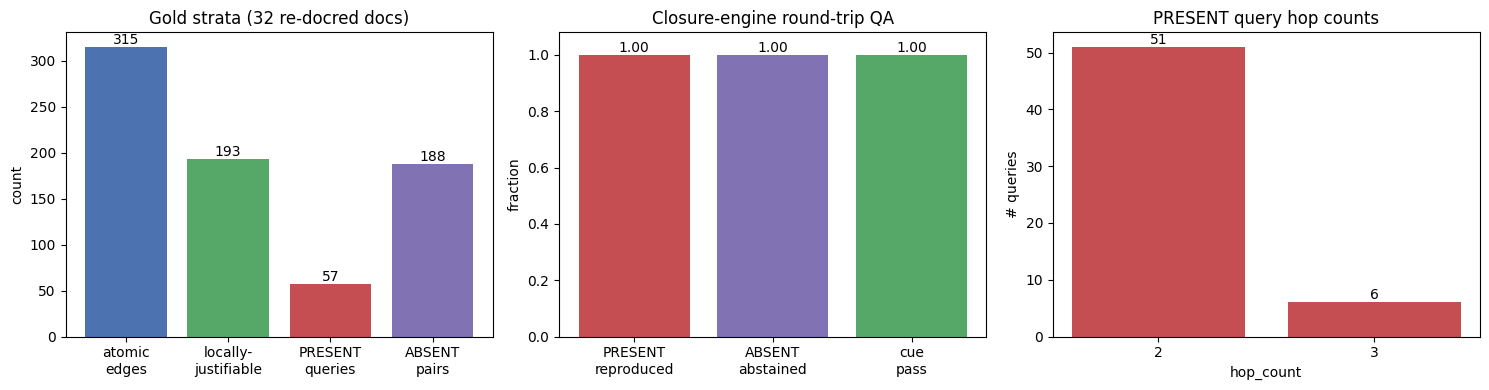


=== SUMMARY ===
documents processed:      32
PRESENT round-trip:       57/57 (100.0%) reproduced as a unique-derivation singleton
ABSENT  no-derivation:    188/188 (100.0%) derive EMPTY => engine abstains (hallucination-safe)
locally-justifiable cue:  193/193 (100.0%) cues present in span


In [10]:
# --- Visualization: strata counts, round-trip accuracy, hop histogram ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) gold strata across processed docs
strata = {"atomic\nedges": n_atomic, "locally-\njustifiable": n_local,
          "PRESENT\nqueries": n_query, "ABSENT\npairs": n_absent}
axes[0].bar(strata.keys(), strata.values(), color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"])
axes[0].set_title(f"Gold strata ({len(docs)} re-docred docs)")
axes[0].set_ylabel("count")
for i, v in enumerate(strata.values()):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# (2) round-trip: present reproduced & absent abstained
labels = ["PRESENT\nreproduced", "ABSENT\nabstained", "cue\npass"]
fracs = [q_ok/max(n_q,1), abs_ok/max(n_abs,1), cue_ok/max(cue_checked,1)]
axes[1].bar(labels, fracs, color=["#C44E52", "#8172B3", "#55A868"])
axes[1].set_ylim(0, 1.08)
axes[1].set_title("Closure-engine round-trip QA")
axes[1].set_ylabel("fraction")
for i, v in enumerate(fracs):
    axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom")

# (3) present-query hop histogram
if hop_hist:
    hops = sorted(hop_hist)
    axes[2].bar([str(h) for h in hops], [hop_hist[h] for h in hops], color="#C44E52")
    for i, h in enumerate(hops):
        axes[2].text(i, hop_hist[h], str(hop_hist[h]), ha="center", va="bottom")
axes[2].set_title("PRESENT query hop counts")
axes[2].set_xlabel("hop_count"); axes[2].set_ylabel("# queries")

plt.tight_layout()
plt.show()

print("\n=== SUMMARY ===")
print(f"documents processed:      {len(docs)}")
print(f"PRESENT round-trip:       {q_ok}/{n_q} ({q_ok/max(n_q,1):.1%}) reproduced as a unique-derivation singleton")
print(f"ABSENT  no-derivation:    {abs_ok}/{n_abs} ({abs_ok/max(n_abs,1):.1%}) derive EMPTY => engine abstains (hallucination-safe)")
print(f"locally-justifiable cue:  {cue_ok}/{cue_checked} ({cue_ok/max(cue_checked,1):.1%}) cues present in span")
